In [8]:
import pandas as pd
import json

# data = json.load(open("logs/outputs/HumanEvalPlus/model_vllm_model_args_pretrained=rasdani__git-diff-Qwen-4B,batch_size=1.json"))
# data = json.load(open("logs/outputs/MBPPPlus/model_vllm_model_args_pretrained=rasdani__git-diff-Qwen-4B,batch_size=1.json"))
# data = json.load(open("logs/outputs/HumanEvalPlus/model_vllm_model_args_pretrained=rasdani__git-diff-Qwen-1.7B,batch_size=1.json"))
# data = json.load(open("logs/outputs/HumanEvalPlus/model_vllm_model_args_pretrained=Qwen__Qwen3-1.7B,batch_size=1.json"))
# data = json.load(open("logs/outputs/MBPPPlus/model_vllm_model_args_pretrained=Qwen__Qwen3-1.7B,batch_size=1.json"))
# data = json.load(open("logs/outputs/MBPPPlus/model_vllm_model_args_pretrained=rasdani__git-diff-Qwen-1.7B,batch_size=1.json"))
# data = json.load(open("logs/outputs/HumanEvalPlus/model_vllm_model_args_pretrained=rasdani__git-diff-Qwen-4B,revision=f004bfd603d690de57053e6dfd2dab066dbf7ac2,batch_size=1.json"))
data = json.load(open("logs/outputs/MBPPPlus/model_vllm_model_args_pretrained=rasdani__git-diff-Qwen-4B,revision=f004bfd603d690de57053e6dfd2dab066dbf7ac2,batch_size=1.json"))

# df = pd.DataFrame(data["python"])
df = pd.DataFrame(data)
df.head()

,task_id,prompt,gpt_completion,generation
0,2,Please refer the given examples and generate a...,"<think>\nOkay, I need to write a Python functi...","def similar_elements(t1, t2):\n return set(..."
1,3,Please refer the given examples and generate a...,"<think>\nOkay, I need to write a Python functi...",import math\n\ndef is_not_prime(n):\n if n ...
2,4,Please refer the given examples and generate a...,"<think>\nOkay, let's see. The user wants a Pyt...",import heapq as hq\n\ndef heap_queue_largest(n...
3,6,Please refer the given examples and generate a...,"<think>\nOkay, I need to write a Python functi...",def is_Power_Of_Two(x: int): \n return x > ...
4,7,Please refer the given examples and generate a...,"<think>\nOkay, I need to write a Python functi...",assert set(find_char_long('Please move back to...


In [9]:
# Calculate lengths of outputs
# output_lengths = df['output'].str.len()
output_lengths = df['gpt_completion'].str.len()
output_lengths.describe()

count       378.000000
mean       8488.473545
std       10999.968497
min        1009.000000
25%        3106.250000
50%        5517.500000
75%        9827.000000
max      144297.000000
Name: gpt_completion, dtype: float64

In [3]:
import datasets

/home/ubuntu/miniforge3/envs/evalchemy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# ds = datasets.Dataset.from_list(data["python"])
ds = datasets.Dataset.from_list(data)
ds

Dataset({
    features: ['task_id', 'prompt', 'gpt_completion', 'generation'],
    num_rows: 378
})

In [11]:
# ds.push_to_hub("rasdani/humanevalplus_git-diff-Qwen-4B")
# ds.push_to_hub("rasdani/mbppplus_git-diff-Qwen-4B")
# ds.push_to_hub("rasdani/humanevalplus_git-diff-Qwen-1.7B")
# ds.push_to_hub("rasdani/humanevalplus_git-diff-Qwen-1.7B")
# ds.push_to_hub("rasdani/humanevalplus_Qwen3-1.7B")
# ds.push_to_hub("rasdani/mbppplus_Qwen3-1.7B")
# ds.push_to_hub("rasdani/mbppplus_git-diff-Qwen-1.7B")
# ds.push_to_hub("rasdani/humanevalplus_git-diff-Qwen-4B_step_445")
ds.push_to_hub("rasdani/mbppplus_git-diff-Qwen-4B_step_445")

Uploading the dataset shards: 100%|██████████| 1/1 [00:01<00:00,  1.34s/it]


CommitInfo(commit_url='https://huggingface.co/datasets/rasdani/mbppplus_git-diff-Qwen-4B_step_445/commit/11175fa2c923f9604f508490acec08d46059d653', commit_message='Upload dataset', commit_description='', oid='11175fa2c923f9604f508490acec08d46059d653', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/rasdani/mbppplus_git-diff-Qwen-4B_step_445', endpoint='https://huggingface.co', repo_type='dataset', repo_id='rasdani/mbppplus_git-diff-Qwen-4B_step_445'), pr_revision=None, pr_num=None)

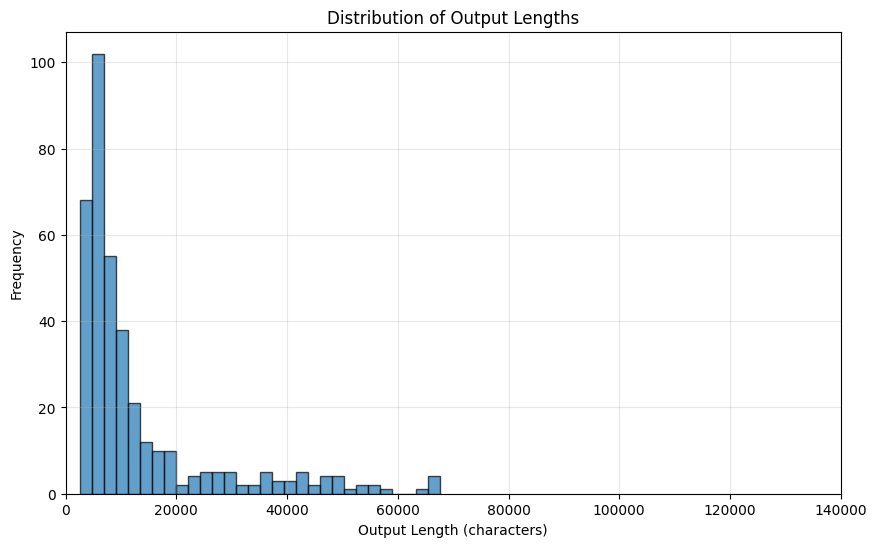

Mean output length: 12983.38 characters
Median output length: 7582.00 characters
Min output length: 2562 characters
Max output length: 67568 characters


In [34]:
import matplotlib.pyplot as plt

# Calculate lengths of outputs
output_lengths = df['gpt_completion'].str.len()
# output_lengths = df['output'].str.len()

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(output_lengths, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Output Length (characters)')
plt.ylabel('Frequency')
plt.title('Distribution of Output Lengths')
plt.xlim(0, 140000)  # Set x-axis limit to 14,000
plt.grid(True, alpha=0.3)
plt.show()

# Print some statistics
print(f"Mean output length: {output_lengths.mean():.2f} characters")
print(f"Median output length: {output_lengths.median():.2f} characters")
print(f"Min output length: {output_lengths.min()} characters")
print(f"Max output length: {output_lengths.max()} characters")
